# Food Delivery Time Prediction

In [190]:
# import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# load the dataset
data = pd.read_csv('./Food_Delivery_Times.csv')

# print the first 5 rows of the dataset
print(data.head())

   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
3                     5                     1.0                 37  
4                    16                     5.0                 68  


In [119]:
data = data.dropna()
data.isnull().sum()

Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

In [120]:
data.count()

Order_ID                  883
Distance_km               883
Weather                   883
Traffic_Level             883
Time_of_Day               883
Vehicle_Type              883
Preparation_Time_min      883
Courier_Experience_yrs    883
Delivery_Time_min         883
dtype: int64

In [121]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 883 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                883 non-null    int64  
 1   Distance_km             883 non-null    float64
 2   Weather                 883 non-null    object 
 3   Traffic_Level           883 non-null    object 
 4   Time_of_Day             883 non-null    object 
 5   Vehicle_Type            883 non-null    object 
 6   Preparation_Time_min    883 non-null    int64  
 7   Courier_Experience_yrs  883 non-null    float64
 8   Delivery_Time_min       883 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 69.0+ KB


In [122]:
encoded_data = pd.get_dummies(
    data,
    columns=["Weather", "Traffic_Level", "Time_of_Day", "Vehicle_Type"],
)

print(encoded_data)

     Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
0         522         7.93                    12                     1.0   
1         738        16.42                    20                     2.0   
2         741         9.52                    28                     1.0   
3         661         7.44                     5                     1.0   
4         412        19.03                    16                     5.0   
..        ...          ...                   ...                     ...   
995       107         8.50                    13                     3.0   
996       271        16.28                     8                     9.0   
997       861        15.62                    26                     2.0   
998       436        14.17                     8                     0.0   
999       103         6.63                    24                     3.0   

     Delivery_Time_min  Weather_Clear  Weather_Foggy  Weather_Rainy  \
0               

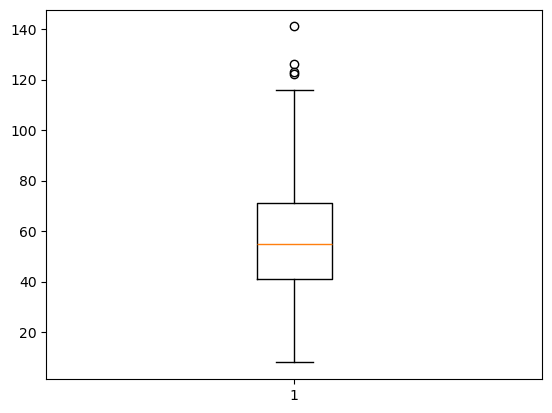

In [169]:
import matplotlib.pyplot as plt

plt.boxplot(encoded_data["Delivery_Time_min"])

plt.show()

In [ ]:
# Q1 = encoded_data["Delivery_Time_min"].quantile(0.25)
# Q3 = encoded_data["Delivery_Time_min"].quantile(0.75)

# IQR = Q3 - Q1

# lower_bound = Q1 - 2 * IQR
# upper_bound = Q3 + 2 * IQR

# outliers = encoded_data[
#     (encoded_data["Delivery_Time_min"] < lower_bound) | (
#         encoded_data["Delivery_Time_min"] > upper_bound)
# ]

# print(outliers)

     Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
127       446        18.97                    25                     4.0   

     Delivery_Time_min  Weather_Clear  Weather_Foggy  Weather_Rainy  \
127                141           True          False          False   

     Weather_Snowy  Weather_Windy  Traffic_Level_High  Traffic_Level_Low  \
127          False          False               False               True   

     Traffic_Level_Medium  Time_of_Day_Afternoon  Time_of_Day_Evening  \
127                 False                  False                 True   

     Time_of_Day_Morning  Time_of_Day_Night  Vehicle_Type_Bike  \
127                False              False              False   

     Vehicle_Type_Car  Vehicle_Type_Scooter  
127              True                 False  


In [ ]:
# updated_data = encoded_data[
#     (encoded_data["Delivery_Time_min"] >= lower_bound) & (encoded_data["Delivery_Time_min"] <= upper_bound)
# ]

In [180]:
train_data, test_data = train_test_split(
    encoded_data, test_size=0.08, random_state=42)

print(f'Training data shape: {train_data.shape}')
print(f'Test data shape: {test_data.shape}')

Training data shape: (812, 20)
Test data shape: (71, 20)


In [181]:
train_features = train_data.drop(['Delivery_Time_min'], axis=1)
train_target = train_data["Delivery_Time_min"]

test_features = test_data.drop(['Delivery_Time_min'], axis=1)
test_target = test_data["Delivery_Time_min"]

In [182]:
print(
    f'minimum delivery time: {train_target.min()} minutes, and maximum delivery time: {train_target.max()} minutes')

minimum delivery time: 13 minutes, and maximum delivery time: 141 minutes


In [183]:
scaler = StandardScaler()

scaler.fit(train_features)

X_train_scaled = scaler.transform(train_features)
X_test_scaled = scaler.transform(test_features)

scaled_data = scaler.fit_transform(train_features)

In [184]:
model = LinearRegression()
model.fit(train_features,train_target)

predictions = model.predict(test_features)

print(model.score(train_features, train_target))
print(model.score(test_features, test_target))

mse = mean_squared_error(test_target, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(test_target, predictions)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R2 Score: {r2}')

0.7755703668445122
0.9136215466223424
Mean Squared Error: 42.63713111893629
Root Mean Squared Error: 6.529711411612023
R2 Score: 0.9136215466223424


In [185]:
print(model.coef_)

[ 2.83509331e-05  2.94071780e+00  9.39468611e-01 -5.67916983e-01
 -4.79432159e+00  2.65445396e+00 -1.46178261e-01  4.87739643e+00
 -2.59135053e+00  6.27235114e+00 -6.10101154e+00 -1.71339605e-01
  9.33575916e-02  9.86425270e-01 -2.07676291e-01 -8.72106570e-01
  1.88181824e-01  7.21383758e-01 -9.09565582e-01]


In [186]:
print(model.intercept_)

16.415204550625816


In [187]:
final_results = pd.DataFrame({
    'Actual': test_target,
    'Predicted': predictions
})

print(final_results)

     Actual  Predicted
48       36  36.114609
910      27  27.288580
816      49  47.991030
748      89  87.423309
995      54  55.109519
..      ...        ...
671      39  36.957127
398      47  50.245816
371      88  82.186599
93       69  72.781330
378      42  42.099352

[71 rows x 2 columns]


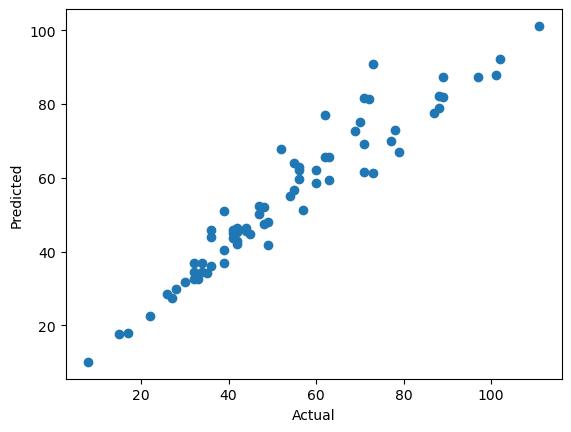

In [188]:
import matplotlib.pyplot as plt

plt.scatter(test_target, predictions)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.show()

In [200]:
features = encoded_data.drop(['Delivery_Time_min'], axis=1)
targets = encoded_data["Delivery_Time_min"]

model_with_cv = LinearRegression()
cv_scores = cross_val_score(model_with_cv, features, targets, cv=5,scoring='r2')

print(f'cross validation scores: {cv_scores.mean().round(4)}')

cross validation scores: 0.7804
